Anaconda

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


PyTorch test code

In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
   print("GPU Name:", torch.cuda.get_device_name(0))
else:
   print("Using CPU for computation.")


PyTorch version: 2.8.0
CUDA available: False
Using CPU for computation.


 Model

100%|██████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:04<00:00, 2.19MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:14<00:00, 115kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.51MB/s]


Start training...
Epoch [1/1], Loss: 0.4324
Training completed!
Start testing...
Accuracy on test set: 89.11%


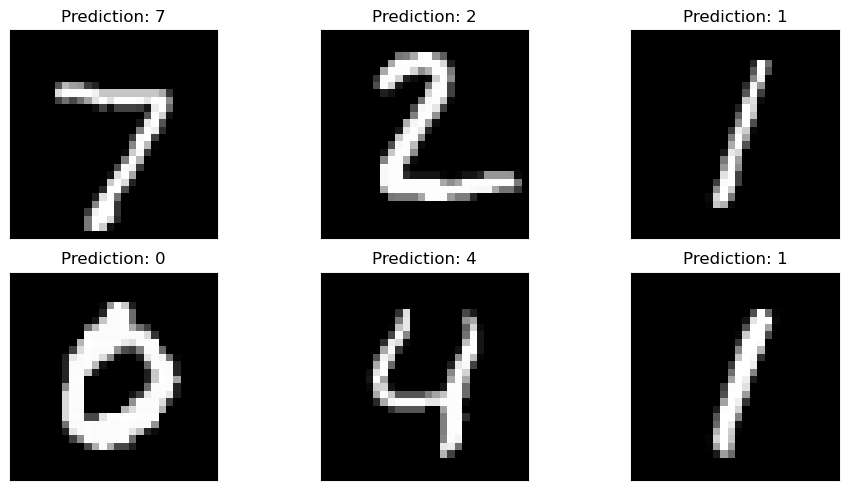

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

# Fix OpenMP issue on some systems
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Hyperparameters
batch_size = 64
learning_rate = 0.01
num_epochs = 1

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Training Dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Load Test Dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Define Neural Network
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)   # Flatten image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


# Create Model
model = SimpleNN()

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training
print("Start training...")

for epoch in range(num_epochs):

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training completed!")

# Testing
print("Start testing...")

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Accuracy on test set: {accuracy:.2f}%')

# Display Predictions
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

output = model(example_data)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(10, 5))

for idx in range(6):

    plt.subplot(2, 3, idx + 1)

    plt.imshow(example_data[idx][0], cmap='gray')
    plt.title(f"Prediction: {preds[idx].item()}")

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

Improved CNN Model for Higher Accuracy

Starting CNN training...
Epoch [1/5] Loss: 0.1850
Epoch [2/5] Loss: 0.0592
Epoch [3/5] Loss: 0.0432
Epoch [4/5] Loss: 0.0350
Epoch [5/5] Loss: 0.0265
CNN training completed!

CNN Test Accuracy: 99.14%


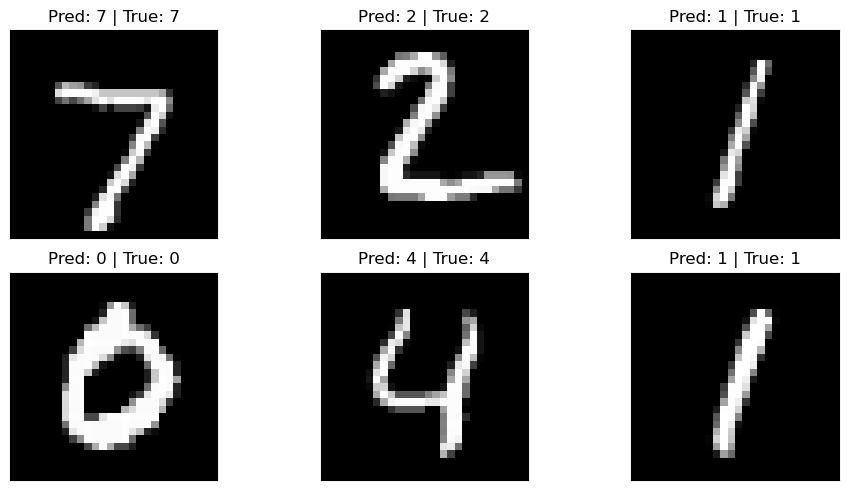

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------------------------------------------------
# Define a Convolutional Neural Network (CNN)
# CNNs work much better for image classification tasks
# because they can learn spatial features like:
# edges, curves, shapes, and patterns.
# ---------------------------------------------------------

class CNNModel(nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        # First convolution layer
        # Input: 1 channel (grayscale image)
        # Output: 32 feature maps
        # Kernel size: 3x3
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max pooling layer
        # Reduces image size by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Activation function
        self.relu = nn.ReLU()

        # Dropout helps prevent overfitting
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers
        # After pooling:
        # 28x28 -> 14x14 -> 7x7
        # Final feature map size:
        # 64 channels × 7 × 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        # Output layer (10 digit classes)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # First convolution block
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Second convolution block
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten feature maps into a vector
        x = x.view(-1, 64 * 7 * 7)

        # Fully connected layer
        x = self.fc1(x)
        x = self.relu(x)

        # Apply dropout
        x = self.dropout(x)

        # Output layer
        x = self.fc2(x)

        return x


# ---------------------------------------------------------
# Create CNN Model
# ---------------------------------------------------------

cnn_model = CNNModel()

# ---------------------------------------------------------
# Loss Function
# CrossEntropyLoss is standard for classification tasks
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# Optimizer
# Adam usually performs much better than SGD for MNIST
# ---------------------------------------------------------

optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# ---------------------------------------------------------
# Train the CNN
# More epochs = better learning
# ---------------------------------------------------------

num_epochs = 5

print("Starting CNN training...")

for epoch in range(num_epochs):

    cnn_model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        # Forward pass
        outputs = cnn_model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {avg_loss:.4f}")

print("CNN training completed!")

# ---------------------------------------------------------
# Evaluate Model Accuracy
# ---------------------------------------------------------

cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        # Get predictions
        outputs = cnn_model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

# Calculate final accuracy
accuracy = 100 * correct / total

print(f"\nCNN Test Accuracy: {accuracy:.2f}%")

# ---------------------------------------------------------
# Display Sample Predictions
# ---------------------------------------------------------

examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

# Generate predictions
output = cnn_model(example_data)
_, preds = torch.max(output, 1)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))

for idx in range(6):

    plt.subplot(2, 3, idx + 1)

    # Show image
    plt.imshow(example_data[idx][0], cmap='gray')

    # Display prediction and actual label
    plt.title(
        f"Pred: {preds[idx].item()} | "
        f"True: {example_targets[idx].item()}"
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()